## Titanic Survival Prediction Project


#### Importing Libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All Libraries are imported")

All Libraries are imported


#### Loading the Dataset for EDA

In [58]:
df = pd.read_csv('train.csv')
print("Dataset is loaded")
print("Here is the data shape:", df.shape)

Dataset is loaded
Here is the data shape: (891, 12)


In [59]:
##### Gonna add head and tail just cuz i wanna do it

df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [60]:
df.tail(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### Gonna use isnull() function without sum() just to understand the difference it makes

In [62]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


#### Just gonna see how many cells are empty per column

In [63]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [64]:
df_clean = df.copy()
print("Data has been copied to new variable")

Data has been copied to new variable


### we are now going to work on handelling the missing values and do it differently for different columns

###### we are going to drop the column cabin becasue it has 687 missing values that is a huge number and will hinder us more than it will help us also it is something if we try to fill in random values they will cause trouble

In [65]:
df_clean=df_clean.drop(columns='Cabin')

###### we are going to drop the ticket column too becasue it has lots of unique values and low predictive power

In [66]:
df_clean=df_clean.drop(columns='Ticket')

###### now we are going to add median age to column age becasue it is fixable with only 177 missing values

In [67]:
# we calculate the median here
median_age = df_clean['Age'].median()
# next we replace the missing values with the median values
df_clean['Age'] = df_clean['Age'].fillna(median_age)

###### next column we are working on is embarked so we are going to fill the column with the ost reoccuring value becasue it is a categorical value

In [68]:
# we are calculating the mode here so that we can use it to fill the values
mode_embarked = df_clean['Embarked'].mode()[0]
# next we just simply fill the values
df_clean['Embarked'] = df_clean['Embarked'].fillna(mode_embarked)

##### okay so filling in the values is done now we check what changes have been done by us

In [69]:
df_clean.shape

(891, 10)

In [70]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Fare         891 non-null    float64
 9   Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(3)
memory usage: 69.7+ KB


In [71]:
df_clean.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


#### Now we are going to perform some analysis we gotta know what we are going to work with

In [72]:
# we are going to understand the survived column here

print("Value count of people who have survived or not survied in the titanic:")
print(df_clean['Survived'].value_counts())
# the value_counts function basically counts as the name suggests

# above we counted the no. of dead or alive people that will be shown in form of 0 and 1

# now ahead we are going to find the percentage survived

print(round(df_clean['Survived'].value_counts(normalize=True)*100,2))

# round rounds off and it will round off to 2 decimal place because we gave that 2
# normalise = true is an argument that is gonna give us a ratio in decimal form and *100 will make it into a percentage

Value count of people who have survived or not survied in the titanic:
Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


##### now we are gonna use groupby basically we will check the survivors according to the gender in next cell in different ways like using sum, mean and value counts function just for the vibes

In [73]:
# we are going to use sum() function first
print("Output using sum() :")
print(df_clean.groupby('Sex')['Survived'].sum())

# we are going to use value_counts() function
print("Output using value_counts() :")
print(df_clean.groupby('Sex')['Survived'].value_counts())

# we are going to use mean() function with *100 and round function and this will print the survival rate
print("Output using mean() :")
print("This gives the surviaval rate according to gender:")
print(round(df_clean.groupby('Sex')['Survived'].mean()*100,2))

Output using sum() :
Sex
female    233
male      109
Name: Survived, dtype: int64
Output using value_counts() :
Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64
Output using mean() :
This gives the surviaval rate according to gender:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64


###### what we used above is groupby function that basically splits the column according to the given categories within the column, it is a very crucial step that helps us dive deep and understand the data better

##### next we do the same for pclass becasue it basically tells the economic class of the people a very crucial thing while talking about the titanic dataset

### Function for categorical values

##### so we have checked the survival according to gender now there is also other categorical values that we need in order to understand our data better but that will make our code repetitive, this is where we will make a function to standardise the processing according to each column seprately

In [74]:
def categorical_data(col):
    # we are going to use mean() function with *100 and round function and this will print the survival rate according to the given column
    print("Output using mean() :")
    print("This gives the survival rate according to",col,":")
    print(round(df_clean.groupby(col)['Survived'].mean()*100,2))

In [75]:
categorical_data('Pclass')

Output using mean() :
This gives the survival rate according to Pclass :
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


In [76]:
categorical_data('Embarked')

Output using mean() :
This gives the survival rate according to Embarked :
Embarked
C    55.36
Q    38.96
S    33.90
Name: Survived, dtype: float64


In [77]:
categorical_data('Sex')

Output using mean() :
This gives the survival rate according to Sex :
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64


In [78]:
categorical_data('SibSp')

Output using mean() :
This gives the survival rate according to SibSp :
SibSp
0    34.54
1    53.59
2    46.43
3    25.00
4    16.67
5     0.00
8     0.00
Name: Survived, dtype: float64


In [79]:
categorical_data('Parch')

Output using mean() :
This gives the survival rate according to Parch :
Parch
0    34.37
1    55.08
2    50.00
3    60.00
4     0.00
5    20.00
6     0.00
Name: Survived, dtype: float64


###### Okai so now we are merging the sibsp and parch columns to make it easier to work it by concerting it into a single unit, this way we can understan another trend of how big or small families on titanic survived

In [80]:
df_clean["Famsize"] = df_clean["SibSp"] + df_clean["Parch"]

print("Famsize column is created successfully")
print(df_clean['Famsize'].value_counts().sort_index())

Famsize column is created successfully
Famsize
0     537
1     161
2     102
3      29
4      15
5      22
6      12
7       6
10      7
Name: count, dtype: int64


###### Now i am gonna create a column called is alone

In [81]:
df_clean['Alone'] = (df_clean['Famsize']==0).astype(int)
print("Alone column is created successfully")
print(df_clean['Alone'].value_counts())

Alone column is created successfully
Alone
1    537
0    354
Name: count, dtype: int64


In [82]:
categorical_data('Famsize')

Output using mean() :
This gives the survival rate according to Famsize :
Famsize
0     30.35
1     55.28
2     57.84
3     72.41
4     20.00
5     13.64
6     33.33
7      0.00
10     0.00
Name: Survived, dtype: float64


In [83]:
categorical_data('Alone')

Output using mean() :
This gives the survival rate according to Alone :
Alone
0    50.56
1    30.35
Name: Survived, dtype: float64


###### right now our data is still very bulky and we still need to remove some irrelevant columns that we are not going to need in this project namely passenger id, name and cabin


In [84]:
# removing passenger id
df_clean = df_clean.drop(columns='PassengerId')
# removing name
df_clean = df_clean.drop(columns='Name')

# i have commented out those lines because when i re-run the code it was throwing error becasue those columns don't exist yk so we can always just un comment these out when we gotta use them

#### Before erncoding

In [85]:
print("Columns before encoding:")
print(df_clean.columns.tolist())

Columns before encoding:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Famsize', 'Alone']


In [86]:
# now we are making a copy of df_clean so that our modelworks
df_model = df_clean.copy()
print("Data has been copied to new variable")

Data has been copied to new variable


## Encoding

In [87]:
# we are gonna use one hot encoding on the categorical data columns that are sex and embarked
# this will make all the categorical or alphabetic data into numerical feature that our ml model will be able to understand

df_model = pd.get_dummies(df_model, columns= ['Sex', 'Embarked'], drop_first = True)
print("Data has been encoded!!!!!")
print("\n New columns after encoding are :")
print(df_model.columns.tolist())

Data has been encoded!!!!!

 New columns after encoding are :
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Famsize', 'Alone', 'Sex_male', 'Embarked_Q', 'Embarked_S']


In [88]:
df_model.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Famsize,Alone,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,0,True,False,True
1,1,1,38.0,1,0,71.2833,1,0,False,False,False
2,1,3,26.0,0,0,7.9250,0,1,False,False,True
3,1,1,35.0,1,0,53.1000,1,0,False,False,True
4,0,3,35.0,0,0,8.0500,0,1,True,False,True


#### i am going to divide df_model into 2 parts X and y, X will be the part with no survived column and y will be the survived column

In [89]:
#X = features (Everthing that the model needs to predict)
#y = Target (What the model has to predict)

X = df_model.drop(columns=['Survived'])
y = df_model['Survived']
print(X.columns.tolist())
y.head()

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Famsize', 'Alone', 'Sex_male', 'Embarked_Q', 'Embarked_S']


,Survived
0,0
1,1
2,1
3,1
4,0


##### now we are going to split the data into training and testing sets

In [90]:
from sklearn.model_selection import train_test_split
#this is where we import the methord we are going to use for splitting the data randomly so that it is useful to predict
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#above we have created 4 variables X_train, X_test, y_train, y_test these variables will store the data that the train test data function will split
# X is divided into X_train and X_test
# y is divided into y_train and y_test

# X_train is training features
# X_test is testing features
# y_train is training target
# y_test is testing target
# test_size = 0.2 basically means take 20 percent data for testing and rest 80 percent for training
# random_state = 42 means nothing tbh it will just help in code reproducibiity the thing is
# 42 is not any specific number just that without it everytime the split will give different results

### now we will train our model and check for accuracy for this we will us sklearn library again

In [91]:
# importing functions from the library
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# training the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
# above lines will train the model using logistic regression
# default max_iter value is 100 and if the model is not completely trained by then it will give a convergence warning
# that is why we are setting the value to a higher number here so that its not excessive but not too less
# oh and max_iter decides the maximum itereations an optimization solver is allowed to find the best model weight
# and model weight is the mathemathical coefficients that determine how much influence each feature must have on the prediction

# now we make predictions
y_predic = model.predict(X_test)

# after we have done with the predictions we check for if our model is predicting the output correctly or no
# like how much of it matches the actual data
accuracy = accuracy_score(y_test, y_predic)
print("Linear Regression Accuracy:", round(accuracy*100),2)

Linear Regression Accuracy: 80 2


#### now because our accuracy is not the best we will use another algorithm to train our model that is random forest

In [92]:
#so we will imprt the library
from sklearn.ensemble import RandomForestClassifier

# following similar stps we will trian the random forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
# above n_estimator tells how many decision trees the random forest will build
# random state does the same thing here too it makes sure that the code produces same results everytime

# we predict the answers and check if they are correct
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(accuracy_rf * 100, 2), "%")

Random Forest Accuracy: 82.68 %


### Feature Importance

In [93]:
# here we will find out which feature was the most important in this whole data frame
# we will determine it according to the random forest

imp_feature = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by= 'Importance', ascending=False)

print("Top most important features are: ", imp_feature.head(4))

Top most important features are:      Feature  Importance
7  Sex_male    0.267175
4      Fare    0.260433
1       Age    0.247282
0    Pclass    0.085761


In [94]:
display(imp_feature)

,Feature,Importance
7,Sex_male,0.267175
4,Fare,0.260433
1,Age,0.247282
0,Pclass,0.085761
5,Famsize,0.043910
2,SibSp,0.029073
9,Embarked_S,0.023787
3,Parch,0.021268
6,Alone,0.011199
8,Embarked_Q,0.010113


##### this next step we will plot graph according to our important features

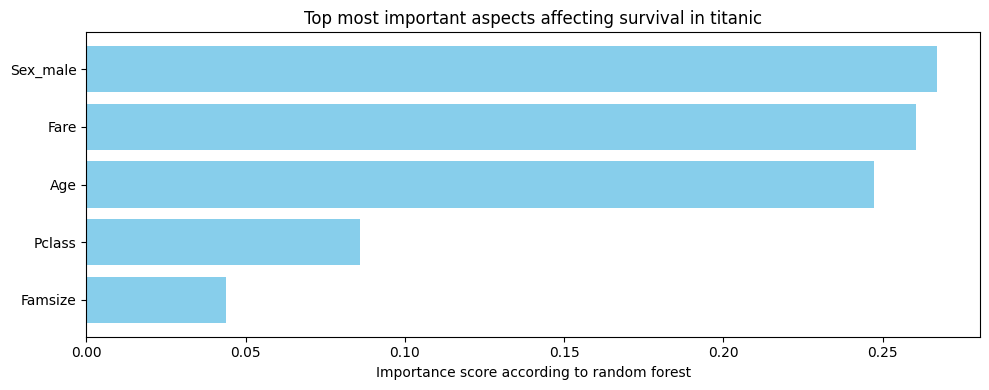

In [95]:
plt.figure(figsize = (10,4))
plt.barh(imp_feature['Feature'][:5], imp_feature['Importance'][:5], color = 'skyblue')
plt.title("Top most important aspects affecting survival in titanic")
plt.xlabel("Importance score according to random forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##### survival by gender and survival by pcalss

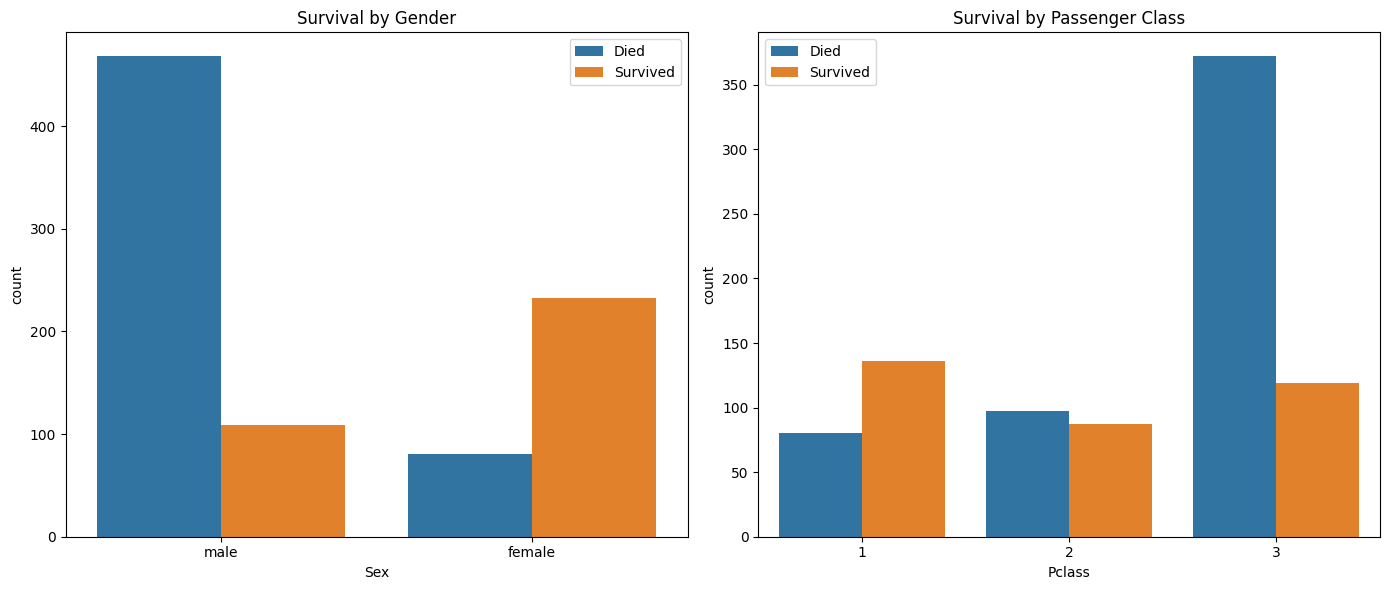

In [96]:
plt.figure(figsize = (14,6))
# we created the canvas for the bar chart

# now we will create a graph for showing survival by gender in titanic
plt.subplot(1,2,1)
# this line creates a singular row and 2 columns basically the arguments withing th parenthesis are (no. of rows, no. of columns, which column to work on)
# that means we will be working on the first column
sns.countplot(data = df_clean, x = 'Sex', hue = 'Survived')
plt.title('Survival by Gender')
plt.legend(['Died','Survived'])

# next we move to survival by passanger class which is an important feature too
plt.subplot(1,2,2)
sns.countplot(data = df_clean, x = 'Pclass', hue = 'Survived')
plt.title ("Survival by Passenger Class")
plt.legend(['Died','Survived'])
plt.tight_layout()
plt.show()

#### survival by age

<function matplotlib.pyplot.show(close=None, block=None)>

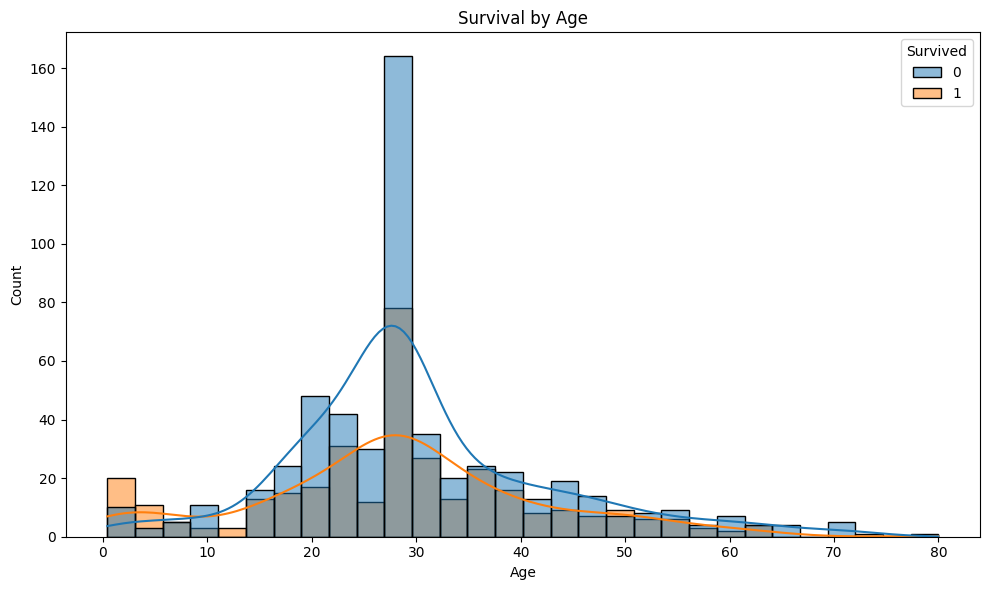

In [97]:
plt.figure(figsize=(10,6))
sns.histplot(data = df_clean, x = 'Age', hue = 'Survived', kde = True, bins = 30)
plt.title('Survival by Age')
plt.tight_layout()
plt.show

#### survival by family size

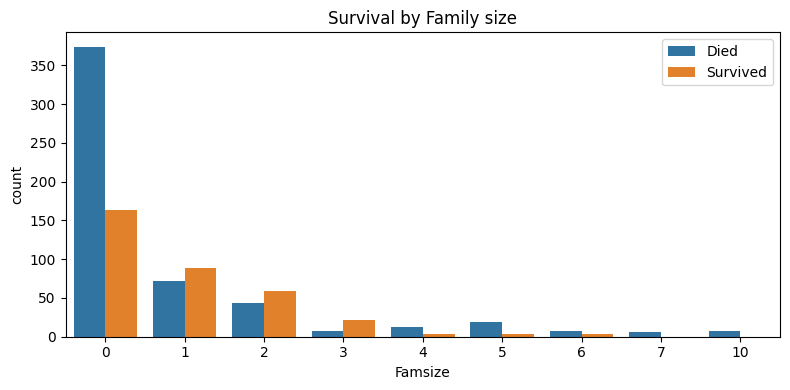

In [98]:
plt.figure(figsize = (8,4))
sns.countplot(data = df_clean, x = 'Famsize', hue = 'Survived')
plt.title("Survival by Family size")
plt.legend(["Died","Survived"])
plt.tight_layout()
plt.show()